In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../src'))

from data_loader import download_price_data, clean_price_data
from factors import compute_momentum, compute_volatility, compute_cross_sectional_zscore

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [9]:
# Using the same MVP universe and dates
mvp_universe = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'JPM', 'JNJ',
    'V', 'PG', 'XOM', 'HD', 'CVX', 'MA', 'BAC', 'ABBV', 'PFE', 'AVGO', 
    'COST', 'DIS', 'KO', 'PEP', 'CSCO', 'WMT', 'TMO', 'MCD', 'ABT', 'CRM'
]

prices_raw, _ = download_price_data(mvp_universe, '2018-01-01', '2026-12-31')
prices = clean_price_data(prices_raw)
returns = prices.pct_change(fill_method=None).dropna()

2026-03-27 12:21:59,637 - INFO - Downloading data for 30 tickers from 2018-01-01 to 2026-12-31...
2026-03-27 12:22:01,259 - INFO - Shape before cleaning: (2069, 30)
2026-03-27 12:22:01,262 - INFO - Shape after cleaning: (2069, 30) (0 dropped)


In [10]:
# 1. Momentum (12M minus 1M)
raw_momentum = compute_momentum(prices)

# 2. Volatility (Trailing 1Y)
raw_volatility = compute_volatility(returns)

# Drop the initial NaN period (we lose the first ~252 days due to the lookback window)
raw_momentum = raw_momentum.dropna(how='all')
raw_volatility = raw_volatility.dropna(how='all')

print("Raw Momentum Head:")
display(raw_momentum.head(3))

2026-03-27 12:22:02,544 - INFO - Computing momentum (lookback=252, skip=21)...
2026-03-27 12:22:02,548 - INFO - Computing annualized rolling volatility (window=252)...


Raw Momentum Head:


Ticker,AAPL,ABBV,ABT,AMZN,AVGO,BAC,BRK-B,COST,CRM,CSCO,...,MSFT,NVDA,PEP,PFE,PG,TMO,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-03,0.052253,-0.004714,0.282652,0.421493,-0.078866,-0.038080,0.106582,0.241009,0.367302,0.269298,...,0.312503,-0.177898,0.058753,0.313984,0.079327,0.296083,0.093439,0.245780,0.008471,-0.026289
2019-01-04,0.089211,-0.026390,0.283624,0.471815,-0.070946,-0.030094,0.105210,0.230534,0.369076,0.282138,...,0.320560,-0.197466,0.035772,0.297549,0.067031,0.285129,0.129992,0.262137,0.011012,-0.024384
2019-01-07,0.036483,-0.053320,0.237851,0.379310,-0.109737,-0.094619,0.046988,0.209545,0.305212,0.242059,...,0.267348,-0.262379,0.020474,0.270797,0.059428,0.228491,0.143284,0.202307,-0.019975,-0.047203


In [11]:
# Standardize Momentum (Higher is better, so keep as is)
z_momentum = compute_cross_sectional_zscore(raw_momentum)

# Standardize Volatility (Lower is better, so we INVERT the z-score)
# A highly volatile stock will get a strongly negative score.
z_low_vol = -compute_cross_sectional_zscore(raw_volatility)

# Let's verify the cross-sectional mean is ~0 and std is ~1 on a random date
sample_date = z_momentum.index[-1]
print(f"On {sample_date.date()}:")
print(f"Momentum Z-Score Mean: {z_momentum.loc[sample_date].mean():.4f}")
print(f"Momentum Z-Score Std:  {z_momentum.loc[sample_date].std():.4f}")

2026-03-27 12:22:03,373 - INFO - Computing cross-sectional z-scores...
2026-03-27 12:22:03,379 - INFO - Computing cross-sectional z-scores...


On 2026-03-26:
Momentum Z-Score Mean: 0.0000
Momentum Z-Score Std:  1.0000


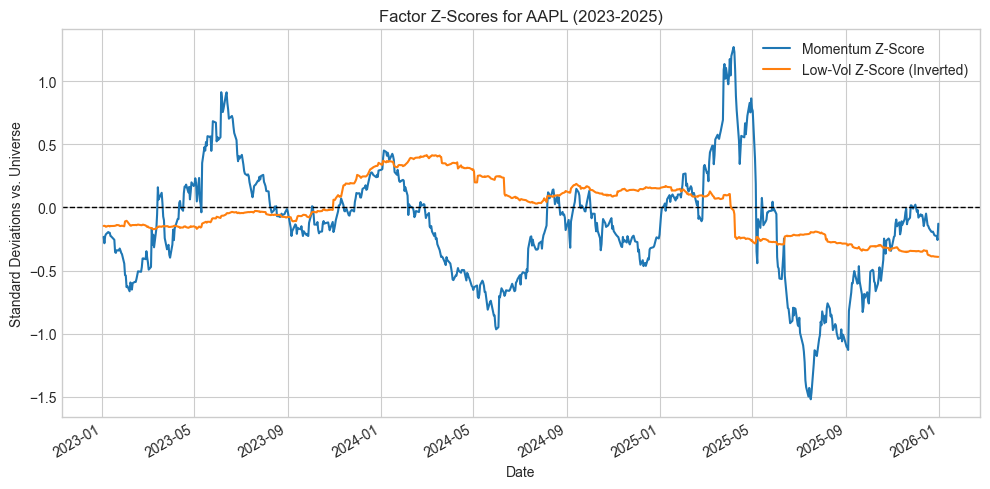

In [13]:
# Let's look at how NVDA's factor profile evolved during 2023
target_ticker = 'AAPL'
plot_data = pd.DataFrame({
    'Momentum Z-Score': z_momentum[target_ticker],
    'Low-Vol Z-Score (Inverted)': z_low_vol[target_ticker]
}).loc['2023-01-01':'2025-12-31']

fig, ax = plt.subplots(figsize=(10, 5))
plot_data.plot(ax=ax, title=f"Factor Z-Scores for {target_ticker} (2023-2025)")
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel("Standard Deviations vs. Universe")
plt.tight_layout()
plt.show()
